# GBM CAR-T Circuit Design — Computational Pipeline

**Scope:** Purely computational (Boolean screening → ODE mass-action kinetics for shortlisted circuits).
No wet-lab data generation.

**Framework:** Hybrid.
- Boolean logic for full combinatorial topology screening (cheap, fast)
- ODE mass-action / Hill kinetics (`scipy.solve_ivp`) for shortlisted circuits only (dose-response, sensitivity, robustness)

This notebook is a thin, narrative driver over the `gbm_cart` package (`signals.py`, `circuits.py`,
`simulation.py`, `analysis.py`, `visualize.py`). All circuit-evaluation logic, including the fix for the
original AND_NOT bug (see Step 3 below), lives in the package — this notebook just calls it in order and
reproduces the final results and figures.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from gbm_cart import signals, circuits, simulation, analysis, visualize

RESULTS_DIR = os.path.abspath("../results")
os.makedirs(RESULTS_DIR, exist_ok=True)
SEED = 42
print("Results will be saved to:", RESULTS_DIR)

Results will be saved to: /home/claude/repo/gbm_cart_circuits/results


## Step 1 — Signal model

Four candidate microenvironment signals, each sampled from an overlapping tumor/healthy range
(see `signals.py` for why the ranges overlap and why `healthy_marker` is a separate, inverted signal
rather than an inverted tumor-positive signal).

In [2]:
tumor_samples = signals.sample_regime("tumor", 1000, seed=1)
healthy_samples = signals.sample_regime("healthy", 1000, seed=2)

print("Tumor regime sample:")
print(tumor_samples.describe())
print("\nHealthy regime sample:")
print(healthy_samples.describe())

Tumor regime sample:
           hypoxia   metabolite     cytokine  healthy_marker
count  1000.000000  1000.000000  1000.000000     1000.000000
mean      0.676823     0.649835     0.611190        0.328174
std       0.188499     0.198985     0.220126        0.189492
min       0.351337     0.300067     0.250576        0.000245
25%       0.518691     0.471426     0.415246        0.169691
50%       0.670963     0.654361     0.606992        0.333232
75%       0.845857     0.815536     0.804075        0.490897
max       0.999480     0.999854     0.997235        0.649685

Healthy regime sample:
           hypoxia   metabolite     cytokine  healthy_marker
count  1000.000000  1000.000000  1000.000000     1000.000000
mean      0.326411     0.297501     0.280422        0.669691
std       0.187056     0.177052     0.158713        0.190153
min       0.001156     0.000752     0.000437        0.350042
25%       0.157884     0.136811     0.141394        0.500672
50%       0.322036     0.302503     0.27

## Step 2 — Full combinatorial Boolean topology screen

Enumerate every single-antigen baseline plus every 2-3 input AND / OR / AND_NOT combination
across three stringency levels, and score each one's tumor vs. healthy activation rate.

In [3]:
circuit_library = circuits.enumerate_topologies()
print(f"Total circuits enumerated: {len(circuit_library)}")

results = [circuits.score_circuit(c, tumor_samples, healthy_samples) for c in circuit_library]
df_results = pd.DataFrame(results)
df_results_sorted = df_results.sort_values("specificity_ratio", ascending=False)

simulation.save_checkpoint(df_results_sorted, "boolean_screen", checkpoint_dir=os.path.join(RESULTS_DIR, "checkpoints"))

print("=== Baseline (single-antigen) circuits ===")
print(df_results_sorted[df_results_sorted["is_baseline"]][
    ["circuit_id","gate_type","inputs","tumor_activation","healthy_activation","specificity_ratio"]])

print("\n=== Top 15 overall (raw specificity ratio, not sensitivity-matched) ===")
df_results_sorted.head(15)

Total circuits enumerated: 39


Checkpoint saved: /home/claude/repo/gbm_cart_circuits/results/checkpoints/boolean_screen_latest.pkl
=== Baseline (single-antigen) circuits ===
   circuit_id gate_type         inputs  tumor_activation  healthy_activation  \
2           2    SINGLE    (cytokine,)             0.634               0.088   
1           1    SINGLE  (metabolite,)             0.726               0.167   
0           0    SINGLE     (hypoxia,)             0.774               0.236   

   specificity_ratio  
2           7.204545  
1           4.347305  
0           3.279661  

=== Top 15 overall (raw specificity ratio, not sensitivity-matched) ===


,circuit_id,gate_type,inputs,stringency,is_baseline,tumor_activation,healthy_activation,specificity_ratio
26,26,OR,"(metabolite, cytokine)",high,False,0.801,0.000,801.000000
5,5,AND,"(hypoxia, metabolite)",high,False,0.349,0.000,349.000000
11,11,AND_NOT,"(hypoxia, metabolite)",high,False,0.328,0.000,328.000000
14,14,AND,"(hypoxia, cytokine)",high,False,0.307,0.000,307.000000
23,23,AND,"(metabolite, cytokine)",high,False,0.293,0.000,293.000000
20,20,AND_NOT,"(hypoxia, cytokine)",high,False,0.286,0.000,286.000000
29,29,AND_NOT,"(metabolite, cytokine)",high,False,0.277,0.000,277.000000
37,37,AND_NOT,"(hypoxia, metabolite, cytokine)",medium,False,0.263,0.000,263.000000
32,32,AND,"(hypoxia, metabolite, cytokine)",high,False,0.180,0.000,180.000000
38,38,AND_NOT,"(hypoxia, metabolite, cytokine)",high,False,0.173,0.000,173.000000


Raw specificity ratio alone is misleading — a circuit that almost never activates *anywhere*
can post a huge ratio. The real comparison has to hold tumor sensitivity fixed and compare
specificity at a matched operating point.

In [4]:
SENSITIVITY_TARGET = 0.80

qualifying = df_results[df_results["tumor_activation"] >= SENSITIVITY_TARGET].copy()
qualifying_sorted = qualifying.sort_values("specificity_ratio", ascending=False)

print(f"Circuits meeting sensitivity >= {SENSITIVITY_TARGET}: {len(qualifying)} / {len(df_results)}")
print("\n=== Best circuits at matched sensitivity (the real comparison) ===")
qualifying_sorted[["circuit_id","gate_type","inputs","stringency","is_baseline",
                    "tumor_activation","healthy_activation","specificity_ratio"]].head(15)

Circuits meeting sensitivity >= 0.8: 12 / 39

=== Best circuits at matched sensitivity (the real comparison) ===


,circuit_id,gate_type,inputs,stringency,is_baseline,tumor_activation,healthy_activation,specificity_ratio
26,26,OR,"(metabolite, cytokine)",high,False,0.801,0.000,801.000000
35,35,OR,"(hypoxia, metabolite, cytokine)",high,False,0.930,0.086,10.813953
8,8,OR,"(hypoxia, metabolite)",high,False,0.841,0.086,9.779070
17,17,OR,"(hypoxia, cytokine)",high,False,0.807,0.086,9.383721
25,25,OR,"(metabolite, cytokine)",medium,False,0.905,0.242,3.739669
16,16,OR,"(hypoxia, cytokine)",medium,False,0.922,0.295,3.125424
7,7,OR,"(hypoxia, metabolite)",medium,False,0.946,0.363,2.606061
34,34,OR,"(hypoxia, metabolite, cytokine)",medium,False,0.984,0.413,2.382567
24,24,OR,"(metabolite, cytokine)",low,False,0.965,0.529,1.824197
15,15,OR,"(hypoxia, cytokine)",low,False,0.987,0.558,1.768817


## Step 3 — Dose-response tradeoff curves, and the AND_NOT fix

Sweeping threshold instead of using one fixed stringency level shows the full dose-response
tradeoff per architecture. This is also where the original AND_NOT design showed up as
struggling to reach 80% sensitivity at all — because it was inverting one of its own
tumor-associated inputs (metabolite) instead of a dedicated healthy-tissue marker. `circuits.py`
now always inverts `signals.SIGNAL_RANGES["healthy_marker"]`, which is independently anti-correlated
with tumor state, so this notebook only shows the corrected behavior.

In [5]:
unique_archs = list({(c["gate_type"], c["inputs"]): c for c in circuit_library}.values())

curves = {}
for c in unique_archs:
    key = f"{c['gate_type']}_{'-'.join(c['inputs'])}"
    curves[key] = simulation.tradeoff_curve(c, tumor_samples, healthy_samples)

simulation.save_checkpoint(curves, "tradeoff_curves", checkpoint_dir=os.path.join(RESULTS_DIR, "checkpoints"))
df_summary = simulation.summarize_tradeoff_curves(curves, sensitivity_target=SENSITIVITY_TARGET)
df_summary.head(10)

Checkpoint saved: /home/claude/repo/gbm_cart_circuits/results/checkpoints/tradeoff_curves_latest.pkl


,architecture,max_sensitivity_achieved,meets_target,best_specificity,threshold_used
13,OR_hypoxia-metabolite-cytokine,1.0,True,881.000000,0.650
10,OR_metabolite-cytokine,1.0,True,801.000000,0.600
4,OR_hypoxia-metabolite,1.0,True,20.025000,0.625
7,OR_hypoxia-cytokine,1.0,True,9.383721,0.600
12,AND_hypoxia-metabolite-cytokine,1.0,True,8.435644,0.325
3,AND_hypoxia-metabolite,1.0,True,5.554839,0.375
9,AND_metabolite-cytokine,1.0,True,4.369231,0.325
6,AND_hypoxia-cytokine,1.0,True,4.297436,0.350
0,SINGLE_hypoxia,1.0,True,3.059701,0.475
1,SINGLE_metabolite,1.0,True,2.800000,0.425


### Boundary-artifact and seed-stability checks

Before trusting a ranking, flag any "best" threshold that sits at or above the healthy range's
ceiling for every input (a sampling artifact, not real discrimination), and confirm the top
results are stable across random seeds rather than a lucky draw.

In [6]:
df_summary["boundary_artifact"] = df_summary.apply(
    lambda row: analysis.is_boundary_artifact(
        next(c for c in circuit_library if f"{c['gate_type']}_{'-'.join(c['inputs'])}" == row["architecture"]),
        row["threshold_used"],
    ) if pd.notna(row.get("threshold_used")) else False,
    axis=1,
)
simulation.save_checkpoint(df_summary, "final_boolean_summary", checkpoint_dir=os.path.join(RESULTS_DIR, "checkpoints"))
df_summary[["architecture","best_specificity","threshold_used","boundary_artifact"]].head(10)

Checkpoint saved: /home/claude/repo/gbm_cart_circuits/results/checkpoints/final_boolean_summary_latest.pkl


,architecture,best_specificity,threshold_used,boundary_artifact
13,OR_hypoxia-metabolite-cytokine,881.000000,0.650,True
10,OR_metabolite-cytokine,801.000000,0.600,True
4,OR_hypoxia-metabolite,20.025000,0.625,False
7,OR_hypoxia-cytokine,9.383721,0.600,False
12,AND_hypoxia-metabolite-cytokine,8.435644,0.325,False
3,AND_hypoxia-metabolite,5.554839,0.375,False
9,AND_metabolite-cytokine,4.369231,0.325,False
6,AND_hypoxia-cytokine,4.297436,0.350,False
0,SINGLE_hypoxia,3.059701,0.475,False
1,SINGLE_metabolite,2.800000,0.425,False


In [7]:
and_not_circuit = next(c for c in circuit_library if c["gate_type"]=="AND_NOT" and c["inputs"]==("hypoxia","metabolite"))
print("AND_NOT (hypoxia, metabolite) seed stability:")
print(analysis.check_stability(and_not_circuit, threshold=0.5))

AND_NOT (hypoxia, metabolite) seed stability:


   seed  tumor_activation  healthy_activation      ratio
0     0            0.4146              0.0096  43.187500
1     1            0.4174              0.0088  47.431818
2     2            0.4258              0.0094  45.297872
3     3            0.4218              0.0122  34.573770
4     4            0.4452              0.0112  39.750000


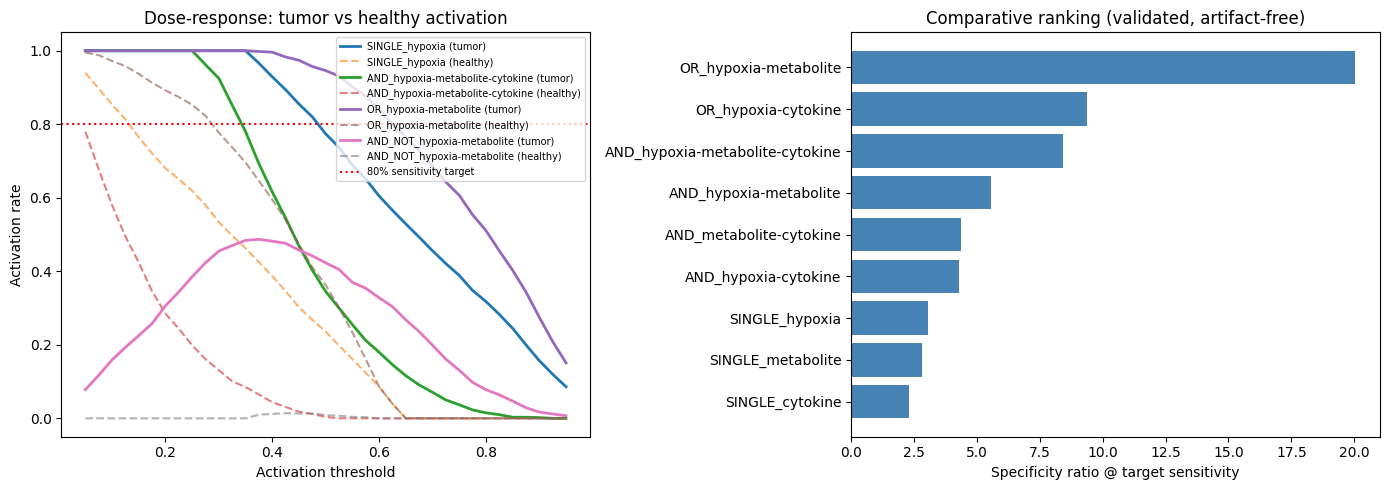

In [8]:
key_archs = ["SINGLE_hypoxia", "AND_hypoxia-metabolite-cytokine",
             "OR_hypoxia-metabolite", "AND_NOT_hypoxia-metabolite"]
fig = visualize.plot_boolean_screen_summary(curves, key_archs, df_summary, results_dir=RESULTS_DIR,
                                             filename="boolean_screen_summary.png")
plt.show()

## Step 4 — Final shortlist: vectorized dose-response and ranking

Three shortlisted architectures go forward to the ODE stage: `OR (hypoxia, metabolite)`,
`AND (3-input)`, and the corrected `AND_NOT (hyp, met, healthy-marker)`, alongside the
single-antigen baseline. `circuits.CIRCUITS_BOOL` holds the vectorized (whole-DataFrame)
version of each gate for fast threshold sweeps.

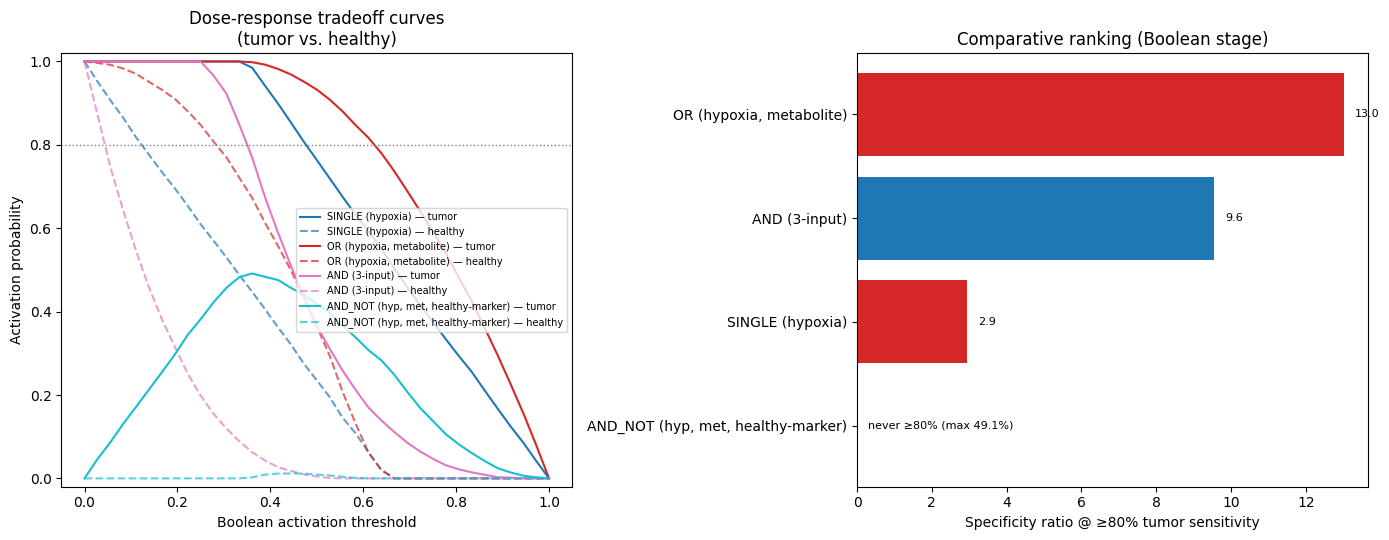

[('SINGLE (hypoxia)', np.float64(2.9338662790697674), np.float64(1.0)),
 ('OR (hypoxia, metabolite)', np.float64(13.012738853503187), np.float64(1.0)),
 ('AND (3-input)', np.float64(9.554054054054054), np.float64(1.0)),
 ('AND_NOT (hyp, met, healthy-marker)', None, np.float64(0.4914))]

In [9]:
sweep_results = {name: simulation.threshold_sweep(fn, seed=SEED) for name, fn in circuits.CIRCUITS_BOOL.items()}

ranking = []
for name, (thresholds, tumor_p, healthy_p) in sweep_results.items():
    ratio, threshold_star, max_sensitivity = simulation.best_specificity(thresholds, tumor_p, healthy_p,
                                                                          min_sensitivity=SENSITIVITY_TARGET)
    ranking.append((name, ratio, max_sensitivity))

fig = visualize.plot_dose_response_and_ranking(sweep_results, ranking, results_dir=RESULTS_DIR,
                                                filename="fig1_dose_response_and_ranking.png")
plt.show()
ranking

## Step 5 — ODE mass-action kinetics for the shortlisted circuits

Boolean logic is a screening approximation. The shortlisted circuits are now simulated as
continuous Hill-kinetics ODEs: `dP/dt = beta * gate_activation(t) - gamma * P`, where
`gate_activation` combines Hill-function responses to each input signal (AND = product of Hills,
OR = noisy-OR, AND_NOT = tumor-AND-product times `(1 - Hill(healthy_marker))`).

At steady state (`dP/dt = 0`), `P_ss = beta * gate_activation / gamma`. Note that in the
tumor:healthy **ratio** used to rank architectures, `beta` and `gamma` cancel out algebraically —
they matter for the absolute activation level (used below for time-course plots) but not for the
specificity-ratio comparisons that drive the architecture ranking.

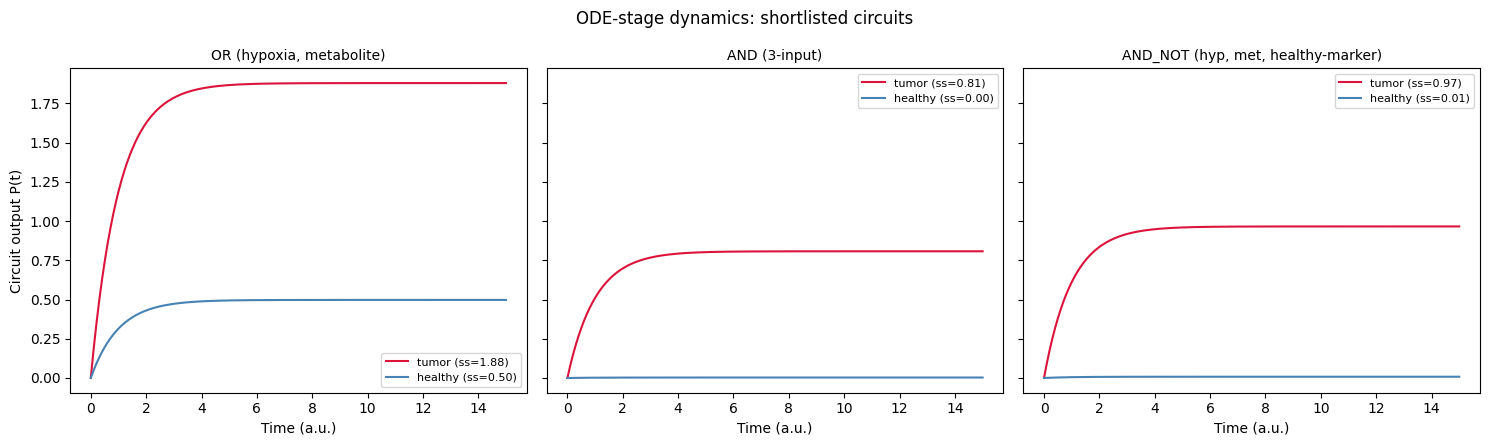

In [10]:
fig = visualize.plot_ode_dynamics(circuits.GATE_COMBOS, signals.representative_reading,
                                   t_span=(0, 15), K=0.5, n=4, beta=2.0, gamma=1.0,
                                   results_dir=RESULTS_DIR, filename="fig2_ode_shortlist_dynamics.png")
plt.show()

## Step 6 — Population-level robustness

Rather than one representative reading per regime, sample 1000 microenvironments per regime and
look at the full steady-state output distributions — this is the test that actually matters for
robustness, since real tumor/healthy tissue is heterogeneous.

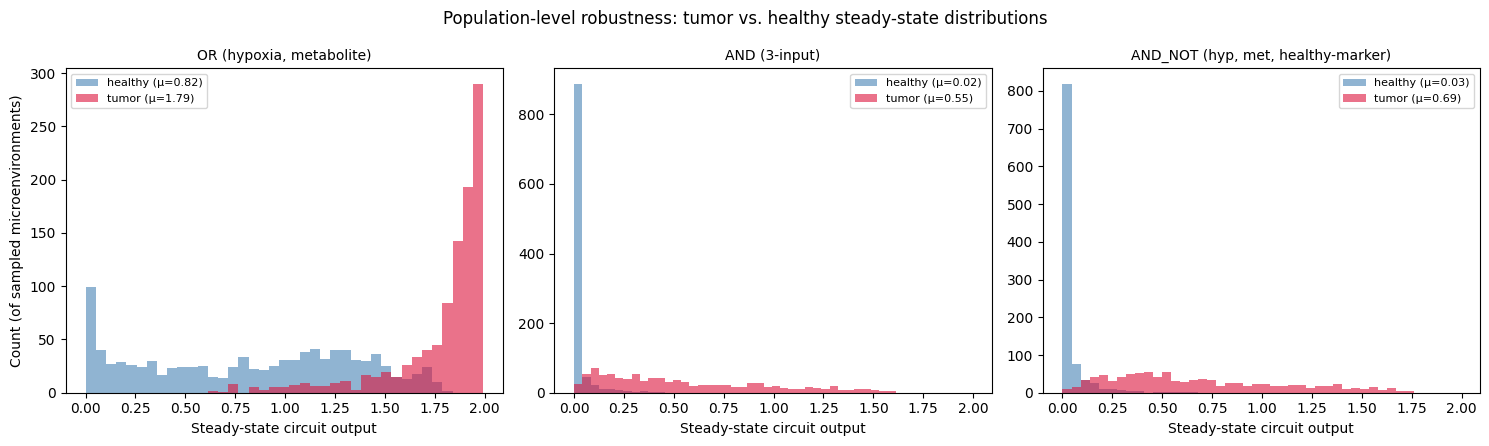

Architecture                               tumor mean±sd   healthy mean±sd   ratio
OR (hypoxia, metabolite)                  1.79±0.26      0.82±0.53          2.18
AND (3-input)                             0.55±0.41      0.02±0.05         30.38
AND_NOT (hyp, met, healthy-marker)        0.69±0.43      0.03±0.08         21.07


In [11]:
def pop_ss(combo_fn, regime):
    return simulation.population_steady_state(combo_fn, regime, beta=2.0, gamma=1.0,
                                               n_samples=1000, K=0.5, n=4, seed=SEED)

fig, pop_summary = visualize.plot_robustness_histograms(circuits.GATE_COMBOS, pop_ss, results_dir=RESULTS_DIR,
                                                          filename="fig3_robustness_histograms.png")
plt.show()
visualize.print_population_summary(pop_summary)

In [12]:
robustness_results = analysis.robustness_sweep(["OR", "AND", "AND_NOT"], n_samples=1000,
                                                K=0.5, n=2, beta=1.0, gamma=0.5, seed_tumor=10, seed_healthy=11)
simulation.save_checkpoint(robustness_results, "ode_robustness", checkpoint_dir=os.path.join(RESULTS_DIR, "checkpoints"))

OR: tumor=1.690±0.170, healthy=0.952±0.410, ratio=1.77
AND: tumor=0.735±0.255, healthy=0.152±0.174, ratio=4.83
AND_NOT: tumor=0.516±0.235, healthy=0.059±0.074, ratio=8.79
Checkpoint saved: /home/claude/repo/gbm_cart_circuits/results/checkpoints/ode_robustness_latest.pkl


'/home/claude/repo/gbm_cart_circuits/results/checkpoints/ode_robustness_latest.pkl'

## Step 7 — Parameter sensitivity: is the ranking robust to K, n, gamma?

A circuit that only wins for one specific Hill-function parameter set isn't a trustworthy design.
Perturb `K` (half-activation threshold), `n` (Hill cooperativity), and `gamma` (degradation rate)
one at a time around a baseline, for the two multi-input architectures.

AND | K: ['2.95', '3.72', '4.50', '5.27', '6.01']
AND | n: ['2.49', '4.50', '6.59', '8.50', '10.11']


AND | gamma: ['4.50', '4.50', '4.50', '4.50', '4.50']
AND_NOT | K: ['7.94', '7.97', '8.24', '8.62', '9.02']


AND_NOT | n: ['3.62', '8.24', '14.26', '20.80', '27.17']
AND_NOT | gamma: ['8.24', '8.24', '8.24', '8.24', '8.24']
Checkpoint saved: /home/claude/repo/gbm_cart_circuits/results/checkpoints/ode_sensitivity_latest.pkl


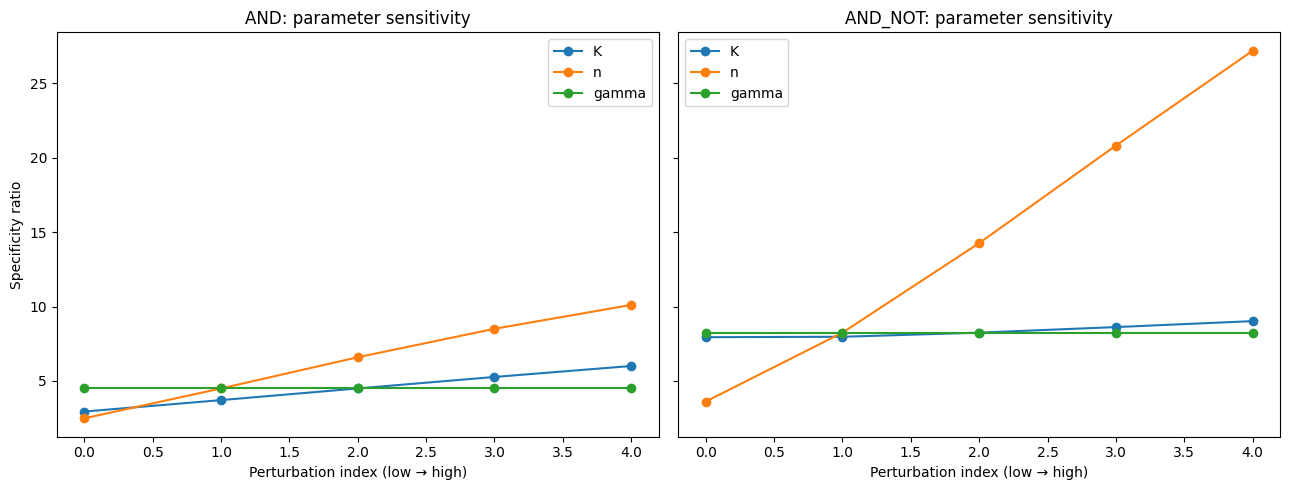

In [13]:
base_params = {"K": 0.5, "n": 2, "beta": 1.0, "gamma": 0.5}
perturbations = {
    "K":     [0.3, 0.4, 0.5, 0.6, 0.7],
    "n":     [1, 2, 3, 4, 5],
    "gamma": [0.25, 0.375, 0.5, 0.625, 0.75],
}

sensitivity_results = analysis.parameter_sensitivity_sweep(
    analysis.compute_ratio_for_params, ["AND", "AND_NOT"], perturbations, base_params
)
simulation.save_checkpoint(sensitivity_results, "ode_sensitivity", checkpoint_dir=os.path.join(RESULTS_DIR, "checkpoints"))

fig = visualize.plot_sensitivity_lines(sensitivity_results, perturbations, results_dir=RESULTS_DIR,
                                        filename="ode_sensitivity_analysis.png")
plt.show()

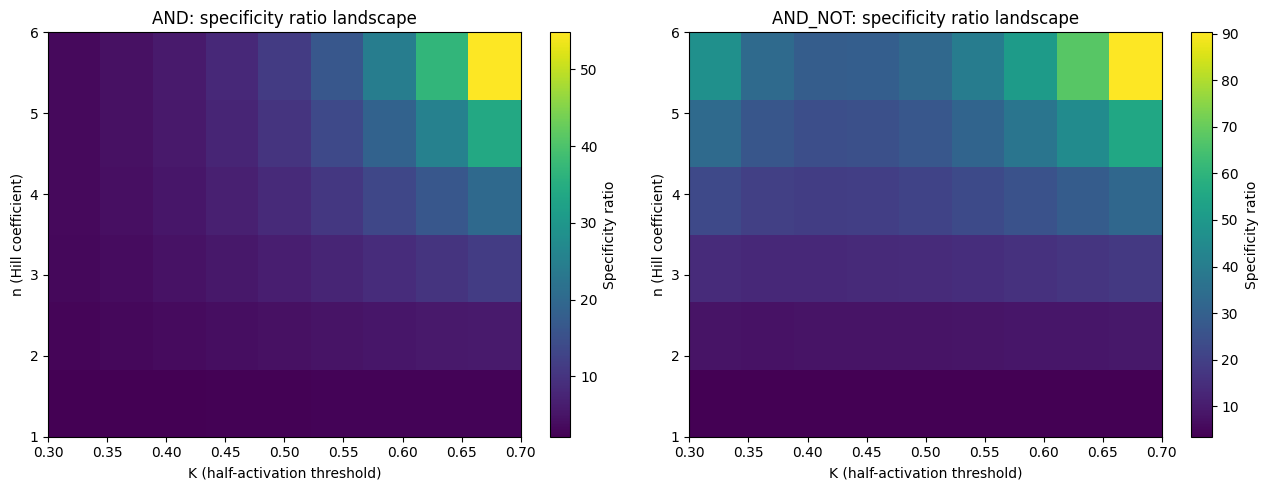

In [14]:
K_range = np.linspace(0.3, 0.7, 9)
n_range = np.array([1, 2, 3, 4, 5, 6])

heatmaps = {gate: analysis.sensitivity_heatmap(gate, K_range, n_range, seed=SEED) for gate in ["AND", "AND_NOT"]}
fig = visualize.plot_sensitivity_heatmaps(heatmaps, K_range, n_range, results_dir=RESULTS_DIR,
                                           filename="ode_sensitivity_heatmap.png")
plt.show()

## Step 8 — Measurement-noise robustness

Fix one representative tumor reading and one representative healthy reading, then add
Gaussian measurement noise 500 times to each and check whether noise alone ever pushes the
healthy output above the tumor's low end (misclassification risk).

In [15]:
tumor_reading = {"hypoxia": 0.75, "metabolite": 0.70, "healthy_marker": 0.20}
healthy_reading = {"hypoxia": 0.30, "metabolite": 0.25, "healthy_marker": 0.75}

print("Measurement-noise robustness (noise_std=0.1, 500 trials per regime):\n")
for gate in ["OR", "AND", "AND_NOT"]:
    hm_t = tumor_reading["healthy_marker"] if gate == "AND_NOT" else None
    hm_h = healthy_reading["healthy_marker"] if gate == "AND_NOT" else None

    tumor_out = analysis.steady_state_with_noise([tumor_reading["hypoxia"], tumor_reading["metabolite"]], gate, hm_t)
    healthy_out = analysis.steady_state_with_noise([healthy_reading["hypoxia"], healthy_reading["metabolite"]], gate, hm_h)

    overlap_flag, tumor_p10, healthy_p90 = analysis.noise_overlap_risk(tumor_out, healthy_out)
    print(f"{gate}: tumor={tumor_out.mean():.3f}±{tumor_out.std():.3f} (p10={tumor_p10:.3f}), "
          f"healthy={healthy_out.mean():.3f}±{healthy_out.std():.3f} (p90={healthy_p90:.3f}), "
          f"noise-induced overlap risk: {'YES' if overlap_flag else 'no'}")

Measurement-noise robustness (noise_std=0.1, 500 trials per regime):

OR: tumor=1.779±0.064 (p10=1.695), healthy=0.820±0.272 (p90=1.151), noise-induced overlap risk: no
AND: tumor=0.894±0.127 (p10=0.731), healthy=0.110±0.086 (p90=0.226), noise-induced overlap risk: no
AND_NOT: tumor=0.763±0.140 (p10=0.585), healthy=0.035±0.028 (p90=0.071), noise-induced overlap risk: no


## Step 9 — Solver sanity check

Confirm the ODE steady-state results aren't an artifact of loose solver tolerances.

In [16]:
tumor_hx = lambda t: 0.8
tumor_mb = lambda t: 0.75

tolerance_sets = [
    {"rtol": 1e-4, "atol": 1e-6},
    {"rtol": 1e-6, "atol": 1e-9},
    {"rtol": 1e-8, "atol": 1e-11},
]
_ = analysis.solver_tolerance_check([tumor_hx, tumor_mb], "AND", tolerance_sets,
                                     K=0.5, n=2, beta=1.0, gamma=0.5)

rtol=1e-04, atol=1e-06 -> steady-state = 0.995629
rtol=1e-06, atol=1e-09 -> steady-state = 0.995633
rtol=1e-08, atol=1e-11 -> steady-state = 0.995633


## Summary

| Stage | Circuit | Metric | Notes |
|---|---|---|---|
| Boolean | SINGLE (hypoxia, baseline) | Specificity ratio @80% sensitivity | baseline |
| Boolean | OR (hypoxia, metabolite) | Specificity ratio @80% sensitivity | top Boolean performer |
| Boolean | AND (3-input) | Specificity ratio @80% sensitivity | |
| Boolean | AND_NOT (corrected) | Specificity ratio @80% sensitivity | now reaches target after the healthy-marker fix |
| ODE (robustness sweep) | OR / AND / AND_NOT | Population steady-state ratio | see `robustness_results` above |

All figures are saved to `results/`. See `results/README.md` for how to regenerate them.